In [8]:
!pip -q install earthengine-api

import ee
import numpy as np
import pandas as pd

ee.Authenticate()

PROJECT = "ee-seismosmsr-gis"

if PROJECT is None:
    ee.Initialize()
else:
    ee.Initialize(project=PROJECT)

# -------------------------------------------------------------------
# Settings
# -------------------------------------------------------------------
MAP_YEAR = 2019
YEAR_START = 2018
YEAR_END = 2024

SAMPLE_POINTS_PER_CLASS = 1000
DW_VALIDATION_POINTS_PER_CLASS = 1000

SAMPLE_SCALE = 10
EMBEDDING_SCALE = 10

TREES = 100
SEED = 42
EPS = 1e-6

AOI = ee.Geometry.Rectangle(
    [-158.35, 21.25, -157.65, 21.75],
    proj="EPSG:4326",
    geodesic=False
)

# -------------------------------------------------------------------
# Datasets
# -------------------------------------------------------------------
embeddings = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
wsf2019 = ee.ImageCollection("projects/sat-io/open-datasets/WSF/WSF_2019")
dynamic_world = ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")

DW_BANDS = [
    "water",
    "trees",
    "grass",
    "flooded_vegetation",
    "crops",
    "shrub_and_scrub",
    "built",
    "bare",
    "snow_and_ice",
]

DW_BUILT_INDEX = DW_BANDS.index("built")

# -------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------
def embeddings_by_year(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, "year")

    return (
        embeddings
        .filterDate(start, end)
        .filterBounds(AOI)
        .mosaic()
        .clip(AOI)
    )


def dynamic_world_built_by_year(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, "year")

    dw = (
        dynamic_world
        .filterDate(start, end)
        .filterBounds(AOI)
        .select(DW_BANDS)
        .median()
        .clip(AOI)
    )

    dw_class = (
        dw
        .toArray()
        .arrayArgmax()
        .arrayGet([0])
        .rename("dw_class")
        .toByte()
    )

    return dw_class.eq(DW_BUILT_INDEX).rename("dw_built").toByte()


def add_p_urban(feature):
    probs = ee.Array(feature.get("probabilities"))
    return feature.set("p_urban", ee.Number(probs.get([1])))


def add_error_fields(y_col):
    def inner(feature):
        y = ee.Number(feature.get(y_col))
        p = ee.Number(feature.get("p_urban"))
        pred = ee.Number(feature.get("classification"))

        err = p.subtract(y)

        return feature.set({
            "error": err,
            "abs_error": err.abs(),
            "sq_error": err.pow(2),
            "tp": pred.multiply(y),
            "fp": pred.multiply(ee.Number(1).subtract(y)),
            "tn": ee.Number(1).subtract(pred).multiply(ee.Number(1).subtract(y)),
            "fn": ee.Number(1).subtract(pred).multiply(y),
        })

    return inner


def add_total_error(y_col, mean_y):
    def inner(feature):
        y = ee.Number(feature.get(y_col))
        return feature.set("sq_total", y.subtract(mean_y).pow(2))

    return inner


def metrics(scored, y_col):
    n = ee.Number(scored.size())
    mean_y = ee.Number(scored.aggregate_mean(y_col))

    scored = scored.map(add_total_error(y_col, mean_y))

    sse = ee.Number(scored.aggregate_sum("sq_error"))
    sst = ee.Number(scored.aggregate_sum("sq_total"))

    tp = ee.Number(scored.aggregate_sum("tp"))
    fp = ee.Number(scored.aggregate_sum("fp"))
    tn = ee.Number(scored.aggregate_sum("tn"))
    fn = ee.Number(scored.aggregate_sum("fn"))

    return ee.Dictionary({
        "n": n,
        "mean_label": mean_y,
        "r2": ee.Number(1).subtract(sse.divide(sst.max(EPS))),
        "rmse": sse.divide(n.max(EPS)).sqrt(),
        "mae": ee.Number(scored.aggregate_sum("abs_error")).divide(n.max(EPS)),
        "bias": ee.Number(scored.aggregate_sum("error")).divide(n.max(EPS)),
        "accuracy": tp.add(tn).divide(n.max(EPS)),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    })


def rf_images_by_year(year):
    img = embeddings_by_year(year)

    p_urban = (
        img
        .classify(probability_classifier, "probabilities")
        .arrayGet([1])
        .rename("p_urban")
    )

    rf_class = (
        img
        .classify(classifier)
        .rename("rf_urban")
        .toByte()
    )

    return p_urban.addBands(rf_class)


def dynamic_world_validation_for_year(year):
    dw_built = dynamic_world_built_by_year(year)

    dw_sample = (
        dw_built
        .stratifiedSample(
            numPoints=DW_VALIDATION_POINTS_PER_CLASS,
            classBand="dw_built",
            region=AOI,
            scale=10,
            geometries=True,
            seed=SEED + year,
            tileScale=4
        )
    )

    rf_img = rf_images_by_year(year)

    scored = (
        rf_img
        .sampleRegions(
            collection=dw_sample,
            properties=["dw_built"],
            scale=10,
            geometries=False,
            tileScale=4
        )
        .filter(ee.Filter.notNull(["p_urban", "rf_urban", "dw_built"]))
        .map(lambda f: f.set("classification", f.get("rf_urban")))
        .map(add_error_fields("dw_built"))
    )

    out = metrics(scored, "dw_built").getInfo()
    out["year"] = year

    return out


def area_for_year(year):
    rf_img = rf_images_by_year(year)
    dw_built = dynamic_world_built_by_year(year)

    pixel_area = ee.Image.pixelArea()

    area_img = ee.Image.cat([
        pixel_area.updateMask(rf_img.select("rf_urban")).rename("rf_area_m2"),
        pixel_area.updateMask(dw_built).rename("dw_area_m2"),
    ])

    stats = area_img.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=AOI,
        scale=10,
        maxPixels=1e13,
        tileScale=4
    )

    return {
        "year": year,
        "rf_area_m2": stats.get("rf_area_m2").getInfo(),
        "dw_area_m2": stats.get("dw_area_m2").getInfo(),
    }


def r2_np(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    keep = np.isfinite(x) & np.isfinite(y)
    x = x[keep]
    y = y[keep]

    sse = np.sum((y - x) ** 2)
    sst = np.sum((x - np.mean(x)) ** 2)

    return 1 - (sse / sst) if sst != 0 else np.nan


# -------------------------------------------------------------------
# WSF 2019 labels
# -------------------------------------------------------------------
label_img = (
    wsf2019
    .filterBounds(AOI)
    .mosaic()
    .gt(0)
    .unmask(0)
    .rename("b1")
    .toByte()
    .clip(AOI)
)

sample = label_img.stratifiedSample(
    numPoints=SAMPLE_POINTS_PER_CLASS,
    classBand="b1",
    region=AOI,
    scale=SAMPLE_SCALE,
    geometries=True,
    seed=SEED,
    tileScale=4
)

map_year_img = embeddings_by_year(MAP_YEAR)
input_properties = map_year_img.bandNames()

labels_and_vectors = (
    map_year_img
    .sampleRegions(
        collection=sample,
        properties=["b1"],
        scale=EMBEDDING_SCALE,
        geometries=True,
        tileScale=4
    )
    .filter(ee.Filter.notNull(input_properties))
    .filter(ee.Filter.inList("b1", [0, 1]))
)

with_random = labels_and_vectors.randomColumn(columnName="random", seed=SEED)

training_set = with_random.filter(ee.Filter.lt("random", 0.7))
validation_set = with_random.filter(ee.Filter.gte("random", 0.7))

# -------------------------------------------------------------------
# Train RF
# -------------------------------------------------------------------
classifier = (
    ee.Classifier
    .smileRandomForest(numberOfTrees=TREES, seed=SEED)
    .train(
        features=training_set,
        classProperty="b1",
        inputProperties=input_properties
    )
)

probability_classifier = (
    ee.Classifier
    .smileRandomForest(numberOfTrees=TREES, seed=SEED)
    .setOutputMode("MULTIPROBABILITY")
    .train(
        features=training_set,
        classProperty="b1",
        inputProperties=input_properties
    )
)

# -------------------------------------------------------------------
# WSF validation
# -------------------------------------------------------------------
wsf_scored = (
    validation_set
    .classify(classifier)
    .classify(probability_classifier, "probabilities")
    .map(add_p_urban)
    .map(add_error_fields("b1"))
)

wsf_metrics = metrics(wsf_scored, "b1").getInfo()

# -------------------------------------------------------------------
# Dynamic World validation and annual area
# -------------------------------------------------------------------
dw_metrics_records = []
area_records = []

for year in range(YEAR_START, YEAR_END + 1):
    dw_metrics_records.append(dynamic_world_validation_for_year(year))
    area_records.append(area_for_year(year))

wsf_metrics_df = pd.DataFrame([wsf_metrics])
dw_metrics_df = pd.DataFrame(dw_metrics_records)
area_df = pd.DataFrame(area_records)

area_df["rf_area_km2"] = area_df["rf_area_m2"] / 1e6
area_df["dw_area_km2"] = area_df["dw_area_m2"] / 1e6
area_df["rf_minus_dw_km2"] = area_df["rf_area_km2"] - area_df["dw_area_km2"]

area_r2 = r2_np(area_df["dw_area_km2"], area_df["rf_area_km2"])

# -------------------------------------------------------------------
# Print results
# -------------------------------------------------------------------
print("\nWSF 2019 held-out validation")
print(
    wsf_metrics_df[
        ["n", "mean_label", "r2", "rmse", "mae", "bias", "accuracy", "tp", "fp", "tn", "fn"]
    ].round(4).to_string(index=False)
)

print("\nDynamic World annual validation")
print(
    dw_metrics_df[
        ["year", "n", "mean_label", "r2", "rmse", "mae", "bias", "accuracy", "tp", "fp", "tn", "fn"]
    ].round(4).to_string(index=False)
)

print("\nAnnual area")
print(
    area_df[
        ["year", "rf_area_km2", "dw_area_km2", "rf_minus_dw_km2"]
    ].round(4).to_string(index=False)
)

print("\nArea R2 against Dynamic World")
print(round(area_r2, 4))


WSF 2019 held-out validation
  n  mean_label     r2   rmse    mae    bias  accuracy  tp  fp  tn  fn
548      0.5693 0.8747 0.1753 0.0871 -0.0061    0.9672 307  13 223   5

Dynamic World annual validation
 year    n  mean_label     r2   rmse    mae    bias  accuracy  tp  fp  tn  fn
 2018 1822      0.5488 0.7866 0.2299 0.1354 -0.0818    0.9116 847   8 814 153
 2019 1838      0.5441 0.7956 0.2252 0.1263 -0.0786    0.9157 851   6 832 149
 2020 1828      0.5470 0.8083 0.2179 0.1239 -0.0731    0.9294 877   6 822 123
 2021 1840      0.5435 0.8203 0.2111 0.1247 -0.0707    0.9424 903   9 831  97
 2022 1836      0.5447 0.7963 0.2248 0.1306 -0.0756    0.9297 880   9 827 120
 2023 1823      0.5485 0.8148 0.2142 0.1285 -0.0709    0.9380 897  10 813 103
 2024 1828      0.5470 0.7709 0.2383 0.1392 -0.0926    0.9070 835   5 823 165

Annual area
 year  rf_area_km2  dw_area_km2  rf_minus_dw_km2
 2018     296.3422     314.0202         -17.6780
 2019     297.1568     322.3933         -25.2365
 2020     3


Annual area estimates
 year  dw_area_km2  rf_area_km2
 2018     314.0202     296.3422
 2019     322.3933     297.1568
 2020     326.1534     313.8622
 2021     331.7267     326.1505
 2022     334.9374     317.7317
 2023     332.3516     324.0378
 2024     333.1105     305.9382

Area agreement metrics
        comparison  n  correlation      r2  rmse_km2  mae_km2  bias_km2
rf_area_vs_dw_area  7       0.7554 -5.6301   17.8688  16.2105  -16.2105


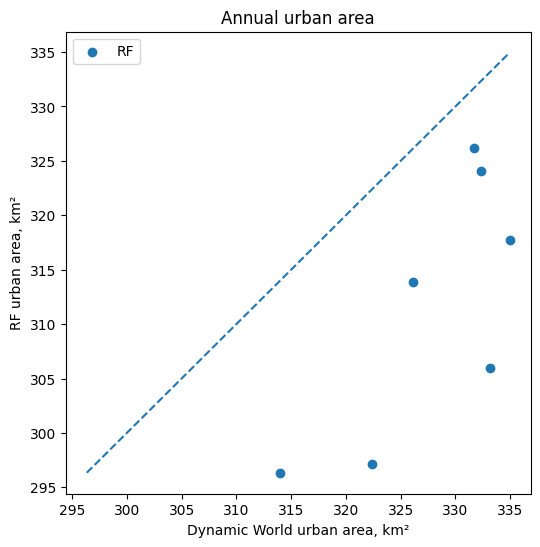

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Uses area_df from the previous cell.
# Expected columns:
# year, rf_area_km2, dw_area_km2

plot_df = area_df.sort_values("year").copy()

def compare_area(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    keep = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[keep]
    y_pred = y_pred[keep]

    err = y_pred - y_true
    sse = np.sum(err ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)

    return {
        "n": len(y_true),
        "correlation": np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan,
        "r2": 1 - (sse / sst) if sst != 0 else np.nan,
        "rmse_km2": np.sqrt(np.mean(err ** 2)),
        "mae_km2": np.mean(np.abs(err)),
        "bias_km2": np.mean(err),
    }

metrics_df = pd.DataFrame([
    {
        "comparison": "rf_area_vs_dw_area",
        **compare_area(plot_df["dw_area_km2"], plot_df["rf_area_km2"])
    }
])

print("\nAnnual area estimates")
print(
    plot_df[
        [
            "year",
            "dw_area_km2",
            "rf_area_km2",
        ]
    ].round(4).to_string(index=False)
)

print("\nArea agreement metrics")
print(metrics_df.round(4).to_string(index=False))

plt.figure(figsize=(6, 6))
plt.scatter(plot_df["dw_area_km2"], plot_df["rf_area_km2"], label="RF")

xmin = min(
    plot_df["dw_area_km2"].min(),
    plot_df["rf_area_km2"].min()
)

xmax = max(
    plot_df["dw_area_km2"].max(),
    plot_df["rf_area_km2"].max()
)

plt.plot([xmin, xmax], [xmin, xmax], linestyle="--")
plt.xlabel("Dynamic World urban area, km²")
plt.ylabel("RF urban area, km²")
plt.title("Annual urban area")
plt.legend()
plt.show()


Year-over-year area deltas
 year  dw_delta_km2  rf_delta_km2
 2019        8.3731        0.8145
 2020        3.7601       16.7055
 2021        5.5733       12.2883
 2022        3.2107       -8.4188
 2023       -2.5859        6.3061
 2024        0.7590      -18.0996

Delta agreement metrics
          comparison  n  correlation       r2  rmse_km2  mae_km2  bias_km2
rf_delta_vs_dw_delta  6       0.2036 -10.6407   11.8305  11.0998   -1.5824


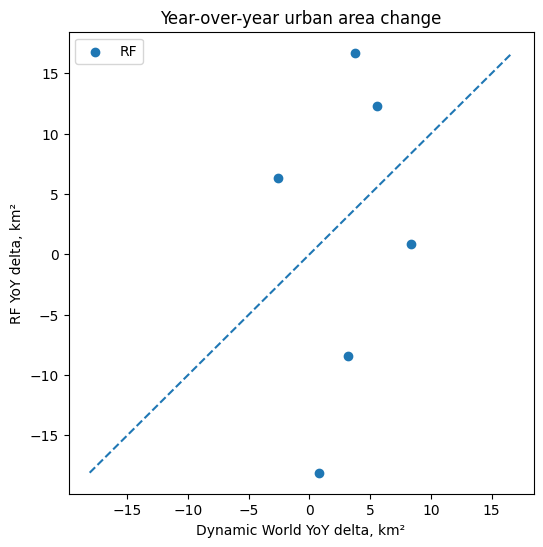

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Uses area_df from the previous cell.
# Expected columns:
# year, rf_area_km2, dw_area_km2

delta_df = area_df.sort_values("year").copy()

delta_df["dw_delta_km2"] = delta_df["dw_area_km2"].diff()
delta_df["rf_delta_km2"] = delta_df["rf_area_km2"].diff()

delta_df = delta_df.dropna().reset_index(drop=True)

def compare_delta(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    keep = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[keep]
    y_pred = y_pred[keep]

    err = y_pred - y_true
    sse = np.sum(err ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)

    return {
        "n": len(y_true),
        "correlation": np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan,
        "r2": 1 - (sse / sst) if sst != 0 else np.nan,
        "rmse_km2": np.sqrt(np.mean(err ** 2)),
        "mae_km2": np.mean(np.abs(err)),
        "bias_km2": np.mean(err),
    }

metrics_df = pd.DataFrame([
    {
        "comparison": "rf_delta_vs_dw_delta",
        **compare_delta(delta_df["dw_delta_km2"], delta_df["rf_delta_km2"])
    }
])

print("\nYear-over-year area deltas")
print(
    delta_df[
        [
            "year",
            "dw_delta_km2",
            "rf_delta_km2",
        ]
    ].round(4).to_string(index=False)
)

print("\nDelta agreement metrics")
print(metrics_df.round(4).to_string(index=False))

plt.figure(figsize=(6, 6))
plt.scatter(delta_df["dw_delta_km2"], delta_df["rf_delta_km2"], label="RF")

xmin = min(
    delta_df["dw_delta_km2"].min(),
    delta_df["rf_delta_km2"].min()
)

xmax = max(
    delta_df["dw_delta_km2"].max(),
    delta_df["rf_delta_km2"].max()
)

plt.plot([xmin, xmax], [xmin, xmax], linestyle="--")
plt.xlabel("Dynamic World YoY delta, km²")
plt.ylabel("RF YoY delta, km²")
plt.title("Year-over-year urban area change")
plt.legend()
plt.show()